In [1]:
# Machine Learning Job Simulation — Business Scaling Project
# InsightSerenity Analytics

# --- STEP 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
# --- STEP 2: Load Datasets ---
users = pd.read_csv('users.csv', parse_dates=['signup_date'])
consultations = pd.read_csv('consultations.csv', parse_dates=['date'])
marketing = pd.read_csv('marketing.csv', parse_dates=['date'])

Users Data Overview:
   user_id  age gender   region signup_date referral_source
0     1001   57      F     East  2024-04-02        LinkedIn
1     1002   34      M    North  2024-03-20      Google Ads
2     1003   32      F  Midwest  2024-04-11        LinkedIn
3     1004   59      M  Midwest  2024-06-04      Google Ads
4     1005   32      F    South  2024-06-24        Referral
\nConsultations Data Overview:
   consultation_id  user_id  consultant_id       date  duration  price  \
0             5001     1934            209 2024-03-23        45     80   
1             5002     1538            211 2024-03-16        45     80   
2             5003     1210            232 2024-03-22        30    120   
3             5004     1604            206 2024-05-11        45     40   
4             5005     1637            216 2024-04-17        60     60   

   completed  
0       True  
1       True  
2      False  
3       True  
4       True  
\nMarketing Data Overview:
   campaign_id     channel

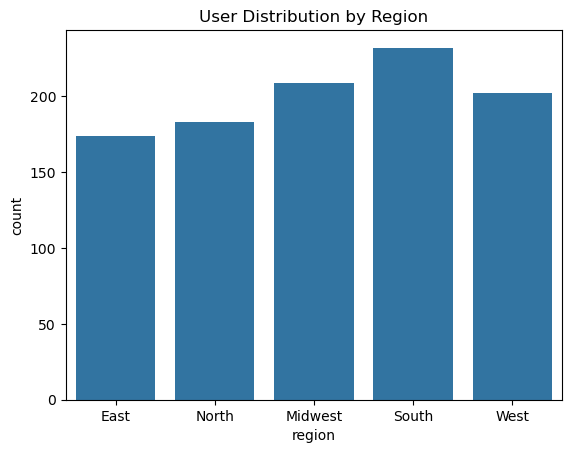

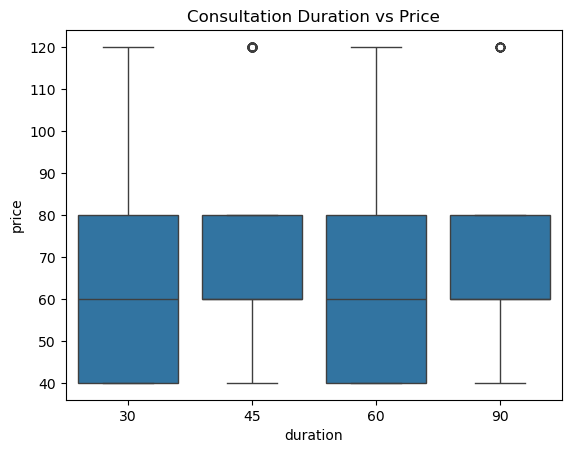

In [4]:
# --- STEP 3: Exploratory Data Analysis ---
print('Users Data Overview:')
print(users.head())

print('\\nConsultations Data Overview:')
print(consultations.head())

print('\\nMarketing Data Overview:')
print(marketing.head())

# --- Example EDA Visualizations ---
sns.countplot(data=users, x='region')
plt.title('User Distribution by Region')
plt.show()

sns.boxplot(data=consultations, x='duration', y='price')
plt.title('Consultation Duration vs Price')
plt.show()

In [6]:
# --- STEP 4: Data Preparation for Modeling ---
# Aggregate user activity (number of consultations, total spend, completion rate)
user_consult_summary = consultations.groupby('user_id').agg({
    'consultation_id': 'count',
    'price': 'sum',
    'completed': 'mean'
}).reset_index()

user_consult_summary.columns = ['user_id', 'num_consultations', 'total_spent', 'completion_rate']

# Merge with user dataset
user_data = users.merge(user_consult_summary, on='user_id', how='left').fillna(0)

# Define target: conversion (at least one completed consultation)
user_data['converted'] = np.where(user_data['num_consultations'] > 0, 1, 0)


In [7]:
# --- STEP 5: Feature Encoding and Splitting ---
features = ['age', 'gender', 'region', 'referral_source', 'num_consultations', 'total_spent', 'completion_rate']
target = 'converted'

# Encode categorical variables
encoded_data = user_data.copy()
for col in ['gender', 'region', 'referral_source']:
    encoded_data[col] = LabelEncoder().fit_transform(encoded_data[col])

X = encoded_data[features]
y = encoded_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train[['age', 'num_consultations', 'total_spent', 'completion_rate']] = scaler.fit_transform(
    X_train[['age', 'num_consultations', 'total_spent', 'completion_rate']])
X_test[['age', 'num_consultations', 'total_spent', 'completion_rate']] = scaler.transform(
    X_test[['age', 'num_consultations', 'total_spent', 'completion_rate']])

In [8]:
# --- STEP 6: Train Predictive Model ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

\nClassification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00       253

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

ROC AUC Score: 1.000


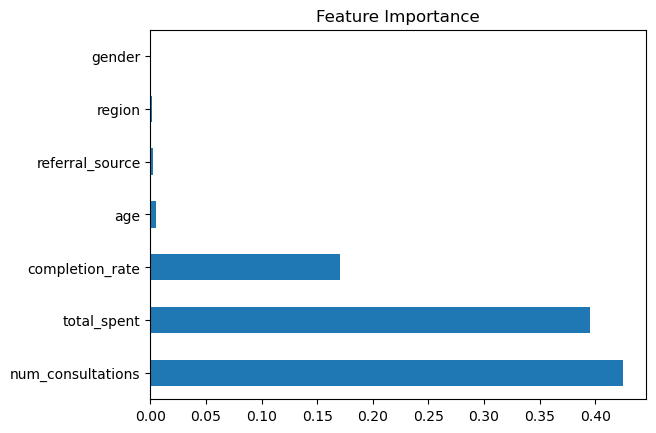

In [9]:
# --- STEP 7: Evaluation ---
print('\\nClassification Report:')
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred)
print(f'ROC AUC Score: {roc_score:.3f}')

# Feature Importance
feat_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
feat_importances.plot(kind='barh', title='Feature Importance')
plt.show()


In [10]:
# --- STEP 8: Insights ---
# Display key insights
print('\\nTop predictive features for conversion:')
print(feat_importances.head())

print('\\nRecommendations:')
print('1. Focus marketing efforts on referral sources and regions with higher conversion rates.')
print('2. Offer incentives or personalized campaigns for high-value users (based on total_spent and completion_rate).')
print('3. Increase duration flexibility or package deals for mid-tier consultations to boost engagement.')

# --- END OF SIMULATION NOTEBOOK ---

\nTop predictive features for conversion:
num_consultations    0.424476
total_spent          0.395122
completion_rate      0.170744
age                  0.005553
referral_source      0.002372
dtype: float64
\nRecommendations:
1. Focus marketing efforts on referral sources and regions with higher conversion rates.
2. Offer incentives or personalized campaigns for high-value users (based on total_spent and completion_rate).
3. Increase duration flexibility or package deals for mid-tier consultations to boost engagement.
